<h1>AD-HOC звіт компанії "Carma kava"</h1>

<h2>Замовник: Олексій Широков</h2>
<h2>Запит: проаналізувати дані продаж за 2025 рік і визначити причину просадки виручки у серпні</h2>

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
%matplotlib inline

In [21]:
data = pd.read_csv('dataframes/carma.csv')
data['order_date'] = pd.to_datetime(data['order_date'])
data['month'] = data['order_date'].dt.month
data.head()

,Unnamed: 0,order_id,order_date,customer_id,product_id,quantity,customer_id.1,customer_name,email,phone_number,...,postcode,loalty_card,product_id.1,coffee_type,roast_type,size,unit_price,price_per_100_g,profit,month
0,0,DCI-96254-548,2025-06-14,94091-86957-HX,A-D-0.2,6,94091-86957-HX,Jimmy Dymoke,jdymokeje@prnewswire.com,3.904599e+09,...,D17,0,A-D-0.2,Ara,D,0.2,2.985,1.4925,0.2686,6.0
1,1,DYG-25473-881,2025-02-08,10138-31681-SD,A-D-0.2,2,10138-31681-SD,Roxine Drivers,rdriversd4@hexun.com,9.131274e+09,...,66276,0,A-D-0.2,Ara,D,0.2,2.985,1.4925,0.2686,2.0
2,2,ESR-66651-814,2025-05-20,76624-72205-CK,A-D-0.2,4,76624-72205-CK,Jasper Sisneros,jsisneros7j@a8.net,9.194489e+09,...,27635,1,A-D-0.2,Ara,D,0.2,2.985,1.4925,0.2686,5.0
3,3,EUH-08089-954,2025-12-06,29050-93691-TS,A-D-0.2,2,29050-93691-TS,Vicki Kirdsch,vkirdsch2o@google.fr,NaN,...,63150,0,A-D-0.2,Ara,D,0.2,2.985,1.4925,0.2686,12.0
4,4,FEO-11834-332,2025-02-11,95399-57205-HI,A-D-0.2,4,95399-57205-HI,Iorgo Kleinert,ikleinertn@timesonline.co.uk,3.603527e+09,...,98682,1,A-D-0.2,Ara,D,0.2,2.985,1.4925,0.2686,2.0


In [22]:
exp = data[['order_id', 'order_date', 'month', 'customer_id', 'product_id', 'quantity', 'loalty_card', 'unit_price',
       'price_per_100_g', 'profit']]

In [23]:
exp

,order_id,order_date,month,customer_id,product_id,quantity,loalty_card,unit_price,price_per_100_g,profit
0,DCI-96254-548,2025-06-14,6.0,94091-86957-HX,A-D-0.2,6,0,2.985,1.4925,0.2686
1,DYG-25473-881,2025-02-08,2.0,10138-31681-SD,A-D-0.2,2,0,2.985,1.4925,0.2686
2,ESR-66651-814,2025-05-20,5.0,76624-72205-CK,A-D-0.2,4,1,2.985,1.4925,0.2686
3,EUH-08089-954,2025-12-06,12.0,29050-93691-TS,A-D-0.2,2,0,2.985,1.4925,0.2686
4,FEO-11834-332,2025-02-11,2.0,95399-57205-HI,A-D-0.2,4,1,2.985,1.4925,0.2686
...,...,...,...,...,...,...,...,...,...,...
753,LWJ-06793-303,2025-01-02,1.0,95424-67020-AP,R-M-2.5,2,1,22.885,0.9154,1.3731
754,QOO-24615-950,2025-08-07,8.0,01338-83217-GV,R-M-2.5,3,0,22.885,0.9154,1.3731
755,SHP-17012-870,2025-06-07,6.0,69529-07533-CV,R-M-2.5,1,1,22.885,0.9154,1.3731
756,TYP-85767-944,2025-07-29,7.0,51497-50894-WU,R-M-2.5,2,1,22.885,0.9154,1.3731


In [24]:
exp['revenue'] = exp['quantity'] * exp['profit']

C:\Users\Viktoria\AppData\Local\Temp\ipykernel_8536\975978225.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exp['revenue'] = exp['quantity'] * exp['profit']


In [25]:
exp.head()

,order_id,order_date,month,customer_id,product_id,quantity,loalty_card,unit_price,price_per_100_g,profit,revenue
0,DCI-96254-548,2025-06-14,6.0,94091-86957-HX,A-D-0.2,6,0,2.985,1.4925,0.2686,1.6116
1,DYG-25473-881,2025-02-08,2.0,10138-31681-SD,A-D-0.2,2,0,2.985,1.4925,0.2686,0.5372
2,ESR-66651-814,2025-05-20,5.0,76624-72205-CK,A-D-0.2,4,1,2.985,1.4925,0.2686,1.0744
3,EUH-08089-954,2025-12-06,12.0,29050-93691-TS,A-D-0.2,2,0,2.985,1.4925,0.2686,0.5372
4,FEO-11834-332,2025-02-11,2.0,95399-57205-HI,A-D-0.2,4,1,2.985,1.4925,0.2686,1.0744


In [26]:
grouped = exp.groupby('month')['revenue'].sum()

In [27]:
new = exp.groupby(['customer_id', 'order_date'])['order_id'].nunique().reset_index()

In [28]:
new['date_next'] = new.groupby('customer_id')['order_date'].shift(-1)

In [29]:
new['coop'] = ( new['date_next'] - new['order_date'] ) / np.timedelta64(1, 'D')

In [30]:
def mask(date_next):
    if date_next != 'NaT' and date_next < 30:
        return 0
    else:
        return 1

In [31]:
new['isnew'] = new['coop'].apply(mask)

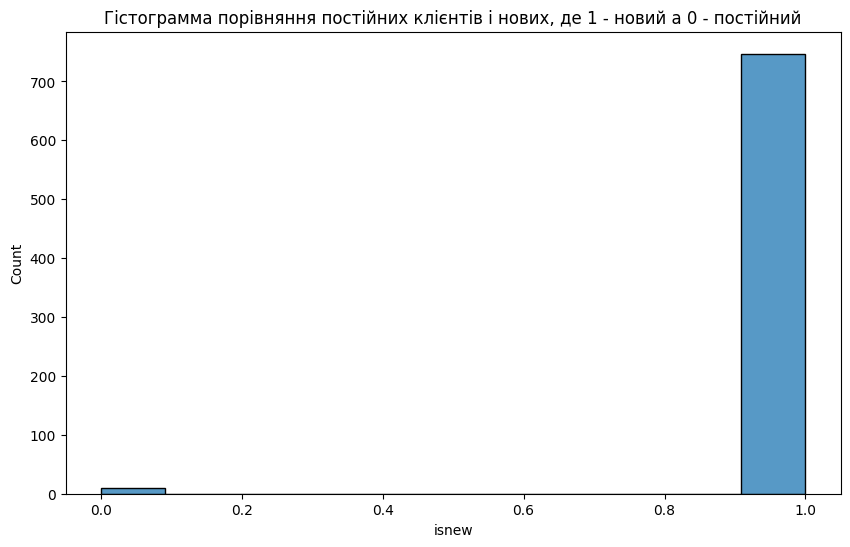

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(new['isnew'])
plt.title('Гістограмма порівняння постійних клієнтів і нових, де 1 - новий а 0 - постійний')
plt.show()

In [33]:
only_new = new[new['isnew'] == 1]
only_new['month'] = only_new['order_date'].dt.month

C:\Users\Viktoria\AppData\Local\Temp\ipykernel_8536\3705291158.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  only_new['month'] = only_new['order_date'].dt.month


In [34]:
only = only_new.groupby('month')['customer_id'].nunique().reset_index()

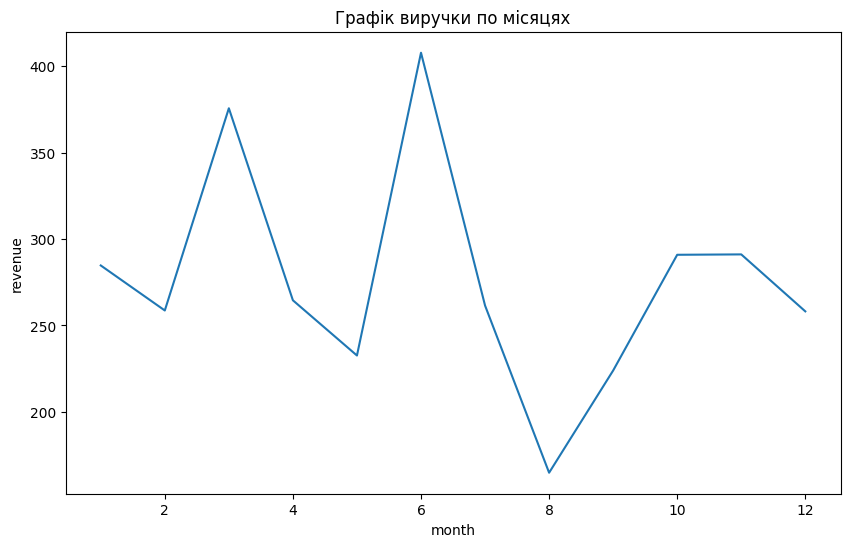

In [35]:
plt.figure(figsize=(10, 6))
sns.lineplot(grouped)
plt.title('Графік виручки по місяцях')
plt.show()

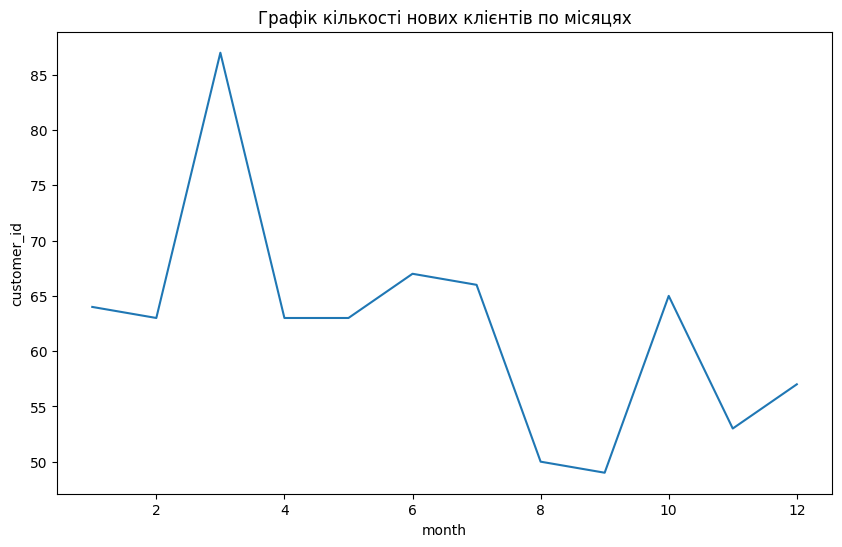

In [36]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=only, x='month', y='customer_id')
plt.title('Графік кількості нових клієнтів по місяцях')
plt.show();

<h1>Висновок: З цих двох графіків ми бачимо значну просадку у виручці і кількості нових клієнтів у серпні і вересні, парні просадки свідчать по недостатнє заохочення нових клієнтів у компанію за період цих місяців</h1>

<h2>Також клієнти дуже рідко повертаються у компанію після першої покупки про що свідчить гістограмма. Це говорить нам про те що у компанії недостанє утримання, і вона повністю залежить від нових клієнтів.</h2>